# UE2: Bildklassifikation von 100 Sportarten mit CNNs

**Datensatz:** [100 Sports Image Classification (Kaggle)](https://www.kaggle.com/datasets/gpiosenka/sports-classification), Version 9  
**Aufgabe:** Vergleich eines eigenen CNNs mit zwei vortrainierten Modellen  
**Namen:** Yannick Höß

In diesem Notebook vergleichen wir drei verschiedene Ansätze für die Klassifikation von Sportbildern.
Das Notebook lädt den Datensatz selbst, kontrolliert die Ordner und Bilder, trainiert die Modelle und
wertet danach auch richtige und falsche Vorhersagen aus. Zusätzliche Python-Dateien werden nicht benötigt.


## 1. Was wir in diesem Notebook umsetzen

Die wichtigsten Punkte aus der Aufgabenstellung sind:

1. kein Toy-Datensatz wie MNIST oder CIFAR-10,
2. zwei unterschiedliche vortrainierte Modelle mit Transfer Learning,
3. ein selbst gebautes CNN,
4. nachvollziehbares Preprocessing und Data Augmentation,
5. ein möglichst fairer Vergleich der Modelle,
6. passende Metriken, eine Confusion Matrix und Beispiele für richtige und falsche Vorhersagen.

Wir verwenden dafür diese drei Modelle:

- **Eigenes CNN:** vier Conv-Blöcke mit Batch Normalization, Pooling und Dropout.
- **MobileNetV2:** ein eher kleines und schnelles vortrainiertes Modell.
- **EfficientNetV2B0:** ein zweites, etwas größeres Transfer-Learning-Modell.

Bei den beiden vortrainierten Modellen trainieren wir zuerst nur den neuen Klassifikationskopf. Danach
geben wir die obersten Schichten des Backbones für ein kurzes Fine-Tuning mit kleiner Lernrate frei.
Die Testdaten verwenden wir erst ganz am Ende.

Für die Umsetzung haben wir vor allem die bisherigen Übungen als Vorlage genommen. Das Laden aus
Klassenordnern, die Augmentation, der CNN-Aufbau, EfficientNet und Grad-CAM kommen aus Übung 3.
Dropout, Batch Normalization und die Functional API wurden in Übung 2 behandelt. Die Darstellung der
Ergebnisse orientiert sich an UE1.


In [32]:
import os

# Damit Keras sicher TensorFlow verwendet. -> LLM Fehlersuche
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import gc
import platform
import time
import warnings
from collections import Counter
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Python: {platform.python_version()}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print("GPU(s):", tf.config.list_physical_devices("GPU"))

Python: 3.13.1
TensorFlow: 2.20.0
Keras: 3.12.0
GPU(s): []


### Vollständiger Lauf und kurzer Testlauf

Normalerweise läuft das Notebook mit allen Bildern und den unten eingestellten Epochen. Falls wir nur
prüfen möchten, ob technisch alles funktioniert, können wir vor dem Kernelstart `SMOKE_TEST == True` setzen.
Dann werden trotzdem alle Modelle, Metriken und Plots ausgeführt, aber nur mit wenigen Batches und einer
Epoche. Die Werte aus diesem kurzen Test sind nicht als Endergebnis gedacht.


In [33]:
SMOKE_TEST = False
SKIP_FINE_TUNING = False

IMG_SIZE = (224, 224)
BATCH_SIZE = 8 if SMOKE_TEST else 32

EPOCHS_CUSTOM = 1 if SMOKE_TEST else 18
EPOCHS_HEAD = 1 if SMOKE_TEST else 8
EPOCHS_FINE = 1 if SMOKE_TEST else 5
PATIENCE = 2 if SMOKE_TEST else 4
SMOKE_BATCHES = 1

print("Modus:", "SMOKE-TEST" if SMOKE_TEST else "VOLLSTÄNDIGES EXPERIMENT")
print(
    {
        "Bildgröße": IMG_SIZE,
        "Batchgröße": BATCH_SIZE,
        "CNN-Epochen": EPOCHS_CUSTOM,
        "Head-Epochen": EPOCHS_HEAD,
        "Fine-Tuning-Epochen": EPOCHS_FINE,
        "Fine-Tuning aktiv": not SKIP_FINE_TUNING,
    }
)

Modus: VOLLSTÄNDIGES EXPERIMENT
{'Bildgröße': (224, 224), 'Batchgröße': 32, 'CNN-Epochen': 18, 'Head-Epochen': 8, 'Fine-Tuning-Epochen': 5, 'Fine-Tuning aktiv': True}


## 2. Datensatz

Der gewählte Kaggle-Datensatz enthält 100 verschiedene Sportarten. Die Bilder liegen bereits in den
Ordnern `train`, `valid` und `test` und haben eine Größe von 224×224 Pixeln. Der Datensatz ist unter
CC0 veröffentlicht.

Wir behalten die vorhandene Aufteilung bei. So gelangen keine Bilder aus dem Testsplit in das Training.
Das mitgelieferte fertige H5-Modell verwenden wir nicht, weil wir die drei Modelle selbst trainieren und
fair vergleichen möchten.

Der Download ist auf Version 9 festgelegt. Wenn der Datensatz schon vorhanden ist, können wir über
`SPORTS_DATASET_DIR` direkt auf diesen Ordner zeigen. Zugangsdaten stehen nicht im Notebook.


In [34]:
import kagglehub

DATASET_HANDLE = "gpiosenka/sports-classification/versions/9"
dataset_override = os.getenv("SPORTS_DATASET_DIR")

if dataset_override:
    DATASET_ROOT = Path(dataset_override).expanduser().resolve()
    print("Nutze lokalen Datensatz:", DATASET_ROOT)
else:
    DATASET_ROOT = Path(kagglehub.dataset_download(DATASET_HANDLE)).resolve()
    print("Kaggle-Cache:", DATASET_ROOT)

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

for split_dir in (TRAIN_DIR, VALID_DIR, TEST_DIR):
    assert split_dir.is_dir(), f"Split-Ordner fehlt: {split_dir}"

Kaggle-Cache: C:\Users\Yannick Höß\.cache\kagglehub\datasets\gpiosenka\sports-classification\versions\9


### Kurzer Datencheck

Wir lesen die Anzahl der Bilder direkt aus den Ordnern aus, weil die Angabe auf Kaggle nicht ganz mit
Version 9 übereinstimmt. Zusätzlich prüfen wir, ob alle drei Splits dieselben Klassen enthalten und ob
defekte oder ungewöhnlich formatierte Bilder vorhanden sind. Die Klassennamen übernehmen wir so, wie sie
im Datensatz stehen.

Diese Ausgaben sind LLM unterstützt entstanden.


In [35]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}


def class_directories(split_dir):
    return sorted(p.name for p in split_dir.iterdir() if p.is_dir())


def image_paths(split_dir):
    return sorted(
        p
        for p in split_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES
    )


class_names = class_directories(TRAIN_DIR)
assert len(class_names) == 100, f"Erwartet: 100 Klassen, gefunden: {len(class_names)}"
assert class_directories(VALID_DIR) == class_names
assert class_directories(TEST_DIR) == class_names

split_paths = {
    "Training": image_paths(TRAIN_DIR),
    "Validierung": image_paths(VALID_DIR),
    "Test": image_paths(TEST_DIR),
}

invalid_images = []
observed_sizes = Counter()
observed_modes = Counter()
for split_name, paths in split_paths.items():
    for path in paths:
        try:
            with Image.open(path) as image:
                observed_sizes[image.size] += 1
                observed_modes[image.mode] += 1
                image.verify()
        except Exception as exc:
            invalid_images.append((split_name, str(path), repr(exc)))

split_summary = pd.DataFrame(
    {
        "Split": list(split_paths),
        "Bilder": [len(paths) for paths in split_paths.values()],
        "Klassen": [
            len(class_directories(d)) for d in (TRAIN_DIR, VALID_DIR, TEST_DIR)
        ],
    }
)
display(split_summary)
print("Häufigste Bildgrößen:", observed_sizes.most_common(5))
print("Bildmodi:", dict(observed_modes))
print("Defekte Bilder:", len(invalid_images))
assert not invalid_images, invalid_images[:5]

,Split,Bilder,Klassen
0,Training,13492,100
1,Validierung,500,100
2,Test,500,100


Häufigste Bildgrößen: [((224, 224), 14492)]
Bildmodi: {'RGB': 14482, 'L': 10}
Defekte Bilder: 0


,Split,Klasse,Anzahl
count,100,100,100.000000
unique,1,100,NaN
top,Training,football,NaN
freq,100,1,NaN
mean,NaN,NaN,134.920000
std,NaN,NaN,21.486044
min,NaN,NaN,59.000000
25%,NaN,NaN,120.750000
50%,NaN,NaN,133.500000
75%,NaN,NaN,148.250000


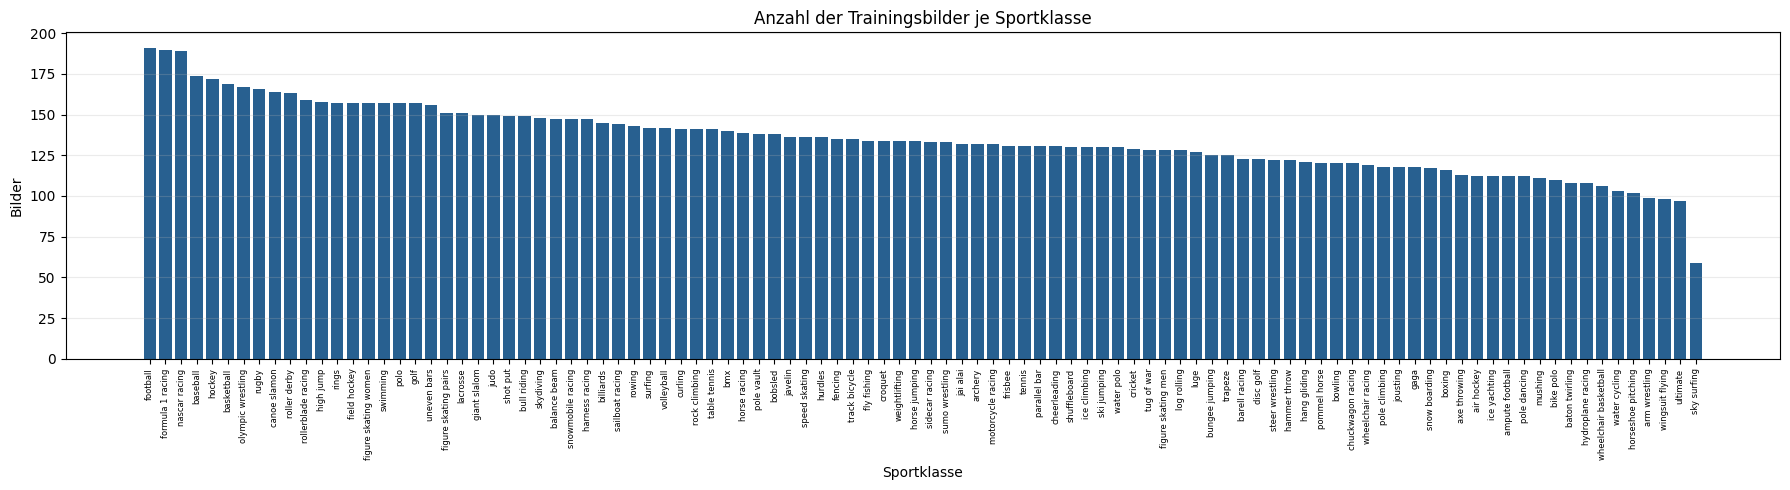

In [36]:
rows = []
for split_name, split_dir in {
    "Training": TRAIN_DIR,
    "Validierung": VALID_DIR,
    "Test": TEST_DIR,
}.items():
    for class_name in class_names:
        count = len(
            [
                p
                for p in (split_dir / class_name).iterdir()
                if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES
            ]
        )
        rows.append({"Split": split_name, "Klasse": class_name, "Anzahl": count})

class_distribution = pd.DataFrame(rows)
train_distribution = class_distribution.query("Split == 'Training'").sort_values(
    "Anzahl", ascending=False
)
display(train_distribution.describe(include="all"))

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(train_distribution["Klasse"], train_distribution["Anzahl"], color="#286090")
ax.set(
    title="Anzahl der Trainingsbilder je Sportklasse",
    xlabel="Sportklasse",
    ylabel="Bilder",
)
ax.tick_params(axis="x", labelrotation=90, labelsize=6)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Bilder mit `tf.data` laden

Wir laden die Bilder batchweise, damit nicht der gesamte Datensatz gleichzeitig im Arbeitsspeicher liegt.
Nur die Trainingsdaten werden gemischt. Für Validierung und Test bleibt die Reihenfolge gleich. Außerdem
verwenden wir für alle Splits genau dieselbe Klassenreihenfolge. Mit `prefetch` kann TensorFlow schon den
nächsten Batch vorbereiten, während das Modell den aktuellen Batch verarbeitet.


In [37]:
def load_split(directory, shuffle):
    return keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        class_names=class_names,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None,
        interpolation="bilinear",
        verbose=True,
    )


train_ds = load_split(TRAIN_DIR, shuffle=True)
valid_ds = load_split(VALID_DIR, shuffle=False)
test_ds = load_split(TEST_DIR, shuffle=False)

autotune = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(autotune)
valid_ds = valid_ds.prefetch(autotune)
test_ds = test_ds.prefetch(autotune)

if SMOKE_TEST:
    train_fit_ds = train_ds.take(SMOKE_BATCHES)
    valid_fit_ds = valid_ds.take(SMOKE_BATCHES)
    test_eval_ds = test_ds.take(SMOKE_BATCHES)
else:
    train_fit_ds = train_ds
    valid_fit_ds = valid_ds
    test_eval_ds = test_ds

sample_images, sample_labels = next(iter(train_fit_ds))
print("Bild-Batch:", sample_images.shape, sample_images.dtype)
print("Label-Batch:", sample_labels.shape, sample_labels.dtype)
print(
    "Pixelbereich:",
    float(tf.reduce_min(sample_images)),
    "bis",
    float(tf.reduce_max(sample_images)),
)

Found 13492 files belonging to 100 classes.
Found 500 files belonging to 100 classes.
Found 500 files belonging to 100 classes.
Bild-Batch: (32, 224, 224, 3) <dtype: 'float32'>
Label-Batch: (32,) <dtype: 'int32'>
Pixelbereich: 0.0 bis 255.0


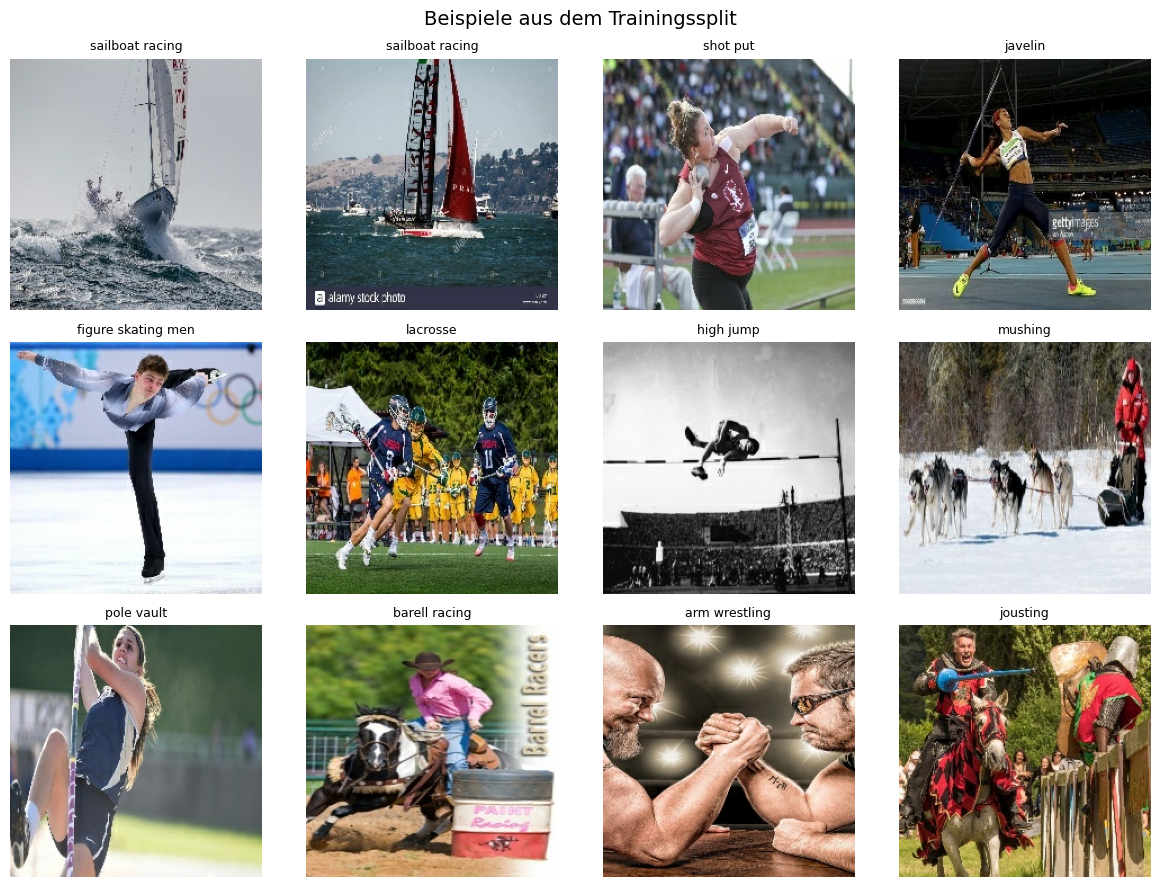

In [38]:
n_show = min(12, len(sample_images))
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, image, label in zip(axes.flat, sample_images[:n_show], sample_labels[:n_show]):
    ax.imshow(tf.cast(image, tf.uint8))
    ax.set_title(class_names[int(label)], fontsize=9)
    ax.axis("off")
for ax in axes.flat[n_show:]:
    ax.axis("off")
fig.suptitle("Beispiele aus dem Trainingssplit", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Preprocessing und Data Augmentation

Für das Training verwenden wir horizontales Spiegeln, kleine Rotationen, leichte Verschiebungen, Zoom und
eine kleine Kontraständerung. Diese Varianten können auch bei echten Sportfotos vorkommen und sollen
verhindern, dass sich ein Modell zu stark einzelne Trainingsbilder merkt.

Nicht verwendet haben wir:

- vertikales Spiegeln, weil kopfstehende Sportler oder Spielfelder meistens nicht sinnvoll sind,
- sehr starke Rotationen oder Crops, weil dabei wichtige Sportgeräte verschwinden könnten,
- Augmentation bei Validierungs- und Testbildern.

Das Preprocessing passiert direkt im jeweiligen Modell. Unser CNN skaliert die Pixel auf `[0, 1]`.
MobileNetV2 benötigt `[-1, 1]`. Bei EfficientNetV2B0 verwenden wir das bereits eingebaute
Keras-Preprocessing. Damit bekommt jedes vortrainierte Modell den Wertebereich, der zu seinen
ImageNet-Gewichten passt.


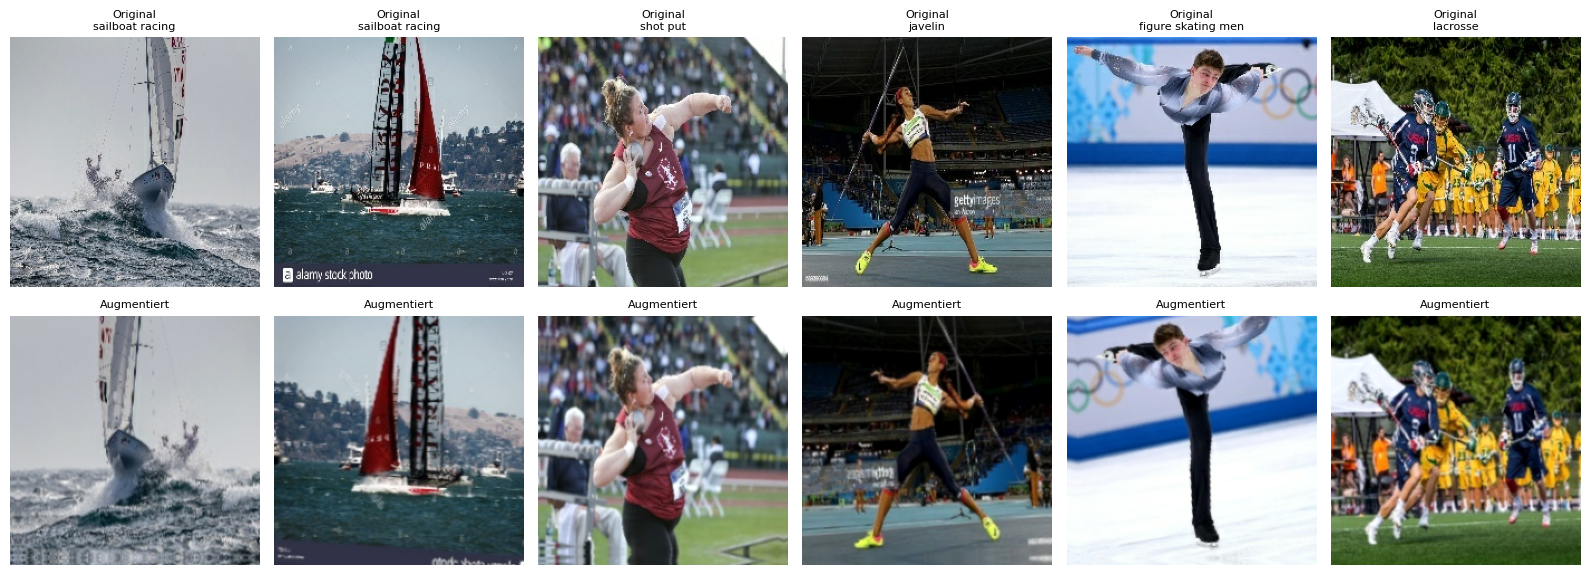

In [39]:
def make_augmentation(name):
    return keras.Sequential(
        [
            keras.layers.RandomFlip("horizontal", seed=SEED),
            keras.layers.RandomRotation(0.06, fill_mode="reflect", seed=SEED + 1),
            keras.layers.RandomTranslation(
                0.05, 0.05, fill_mode="reflect", seed=SEED + 2
            ),
            keras.layers.RandomZoom(0.10, fill_mode="reflect", seed=SEED + 3),
            keras.layers.RandomContrast(0.10, seed=SEED + 4),
        ],
        name=name,
    )


augmentation_preview = make_augmentation("augmentation_preview")
augmented_images = augmentation_preview(sample_images[:6], training=True)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i in range(min(6, len(sample_images))):
    axes[0, i].imshow(tf.cast(sample_images[i], tf.uint8))
    axes[0, i].set_title(f"Original\n{class_names[int(sample_labels[i])]}", fontsize=8)
    axes[1, i].imshow(tf.cast(tf.clip_by_value(augmented_images[i], 0, 255), tf.uint8))
    axes[1, i].set_title("Augmentiert", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## 5. Training und gewählte Einstellungen

Damit der Vergleich möglichst fair bleibt, verwenden wir für alle Modelle dieselben Daten, dieselbe
Augmentation, Adam, Cross-Entropy, Early Stopping und Reduce-on-Plateau. Das eigene CNN und die neuen
Klassifikationsköpfe starten mit einer Lernrate von `1e-3`. Beim Fine-Tuning reduzieren wir sie auf
`1e-5`, damit die bereits gelernten Gewichte nicht zu stark verändert werden.

Neben Accuracy berechnen wir Macro-F1, weil dabei jede der 100 Klassen gleich viel zählt. Top-5-Accuracy
ist bei so vielen Klassen ebenfalls interessant, weil sie zeigt, ob die richtige Sportart zumindest
unter den fünf wahrscheinlichsten Vorhersagen liegt.


In [40]:
NUM_CLASSES = len(class_names)


def compile_classifier(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
        ],
    )


def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=max(1, PATIENCE // 2),
            min_lr=1e-7,
            verbose=1,
        ),
    ]


def fit_model(model, epochs, phase_name):
    start = time.perf_counter()
    history = model.fit(
        train_fit_ds,
        validation_data=valid_fit_ds,
        epochs=epochs,
        callbacks=make_callbacks(),
        verbose=2,
    )
    seconds = time.perf_counter() - start
    print(f"{phase_name}: {seconds:.1f} Sekunden")
    return history.history, seconds


def count_trainable_parameters(model):
    return int(sum(np.prod(v.shape) for v in model.trainable_weights))


histories = {}
training_seconds = {}
models = {}
transfer_components = {}

## 6. Eigenes CNN

Unser eigenes Modell besteht aus vier Conv-Blöcken. Nach jeder Faltung folgen Batch Normalization,
ReLU, Max Pooling und etwas Dropout. Die Anzahl der Filter steigt von Block zu Block.

Am Ende verwenden wir `GlobalAveragePooling2D` statt `Flatten`. Bei 224×224-Bildern würde ein großer
Flatten-Head sehr viele zusätzliche Parameter erzeugen. Alle Gewichte dieses Modells werden nur mit
dem Sportdatensatz gelernt.


In [41]:
def build_custom_cnn():
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    x = make_augmentation("custom_augmentation")(inputs)
    x = keras.layers.Rescaling(1.0 / 255.0, name="custom_rescaling")(x)

    for block_index, filters in enumerate((32, 64, 128, 256), start=1):
        x = keras.layers.Conv2D(
            filters,
            3,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"custom_conv_{block_index}",
        )(x)
        x = keras.layers.BatchNormalization(name=f"custom_bn_{block_index}")(x)
        x = keras.layers.Activation("relu", name=f"custom_relu_{block_index}")(x)
        x = keras.layers.MaxPooling2D(2, name=f"custom_pool_{block_index}")(x)
        x = keras.layers.Dropout(
            0.10 + 0.05 * block_index, name=f"custom_drop_{block_index}"
        )(x)

    x = keras.layers.GlobalAveragePooling2D(name="custom_gap")(x)
    x = keras.layers.Dense(256, activation="relu", name="custom_dense")(x)
    x = keras.layers.Dropout(0.40, name="custom_head_dropout")(x)
    outputs = keras.layers.Dense(
        NUM_CLASSES, activation="softmax", name="custom_predictions"
    )(x)
    model = keras.Model(inputs, outputs, name="Eigenes_CNN")
    compile_classifier(model, learning_rate=1e-3)
    return model


custom_model = build_custom_cnn()
assert custom_model.output_shape == (None, NUM_CLASSES)
custom_model.summary()

custom_history, custom_seconds = fit_model(custom_model, EPOCHS_CUSTOM, "Eigenes CNN")
models["Eigenes CNN"] = custom_model
histories["Eigenes CNN"] = {"head": custom_history, "fine": {}}
training_seconds["Eigenes CNN"] = custom_seconds

Model: "Eigenes_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_rescaling (Rescaling)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_conv_1 (Conv2D)          │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_bn_1                     │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_relu_1 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_pool_1 (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_drop_1 (Dropout)         │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_conv_2 (Conv2D)          │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_bn_2                     │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_relu_2 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_pool_2 (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_drop_2 (Dropout)         │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_conv_3 (Conv2D)          │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_bn_3                     │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_relu_3 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_pool_3 (MaxPooling2D)    │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_drop_3 (Dropout)         │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_conv_4 (Conv2D)          │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_bn_4                     │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_relu_4 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_pool_4 (MaxPooling2D)    │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 481,348 (1.84 MB)

 Trainable params: 480,388 (1.83 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/18


KeyboardInterrupt: 

## 7. Transfer Learning mit MobileNetV2 und EfficientNetV2B0

Bei beiden Modellen frieren wir den ImageNet-Backbone zuerst vollständig ein. In dieser Phase wird nur
der neue Kopf für die 100 Sportklassen trainiert. Danach geben wir die obersten 20 % der
Backbone-Schichten frei. Batch-Normalization-Schichten bleiben dabei eingefroren.

MobileNetV2 dient als kleinere und schnellere Variante. EfficientNetV2B0 ist etwas größer und anders
aufgebaut. Dadurch vergleichen wir nicht zweimal fast dasselbe Modell.


In [ ]:
def build_transfer_model(backbone_name):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name=f"{backbone_name}_image")
    augmentation = make_augmentation(f"{backbone_name}_augmentation")

    if backbone_name == "MobileNetV2":
        preprocessing = keras.Sequential(
            [
                augmentation,
                keras.layers.Rescaling(
                    scale=1.0 / 127.5,
                    offset=-1.0,
                    name="mobilenetv2_rescaling",
                ),
            ],
            name="mobilenetv2_preprocessing",
        )
        base = keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=(*IMG_SIZE, 3),
        )
    elif backbone_name == "EfficientNetV2B0":
        preprocessing = keras.Sequential(
            [augmentation],
            name="efficientnetv2b0_preprocessing",
        )
        base = keras.applications.EfficientNetV2B0(
            include_top=False,
            weights="imagenet",
            input_shape=(*IMG_SIZE, 3),
            include_preprocessing=True,
        )
    else:
        raise ValueError(f"Unbekannter Backbone: {backbone_name}")

    base.trainable = False
    head = keras.Sequential(
        [
            keras.layers.GlobalAveragePooling2D(name=f"{backbone_name}_gap"),
            keras.layers.Dense(256, activation="relu", name=f"{backbone_name}_dense"),
            keras.layers.Dropout(0.35, name=f"{backbone_name}_dropout"),
            keras.layers.Dense(
                NUM_CLASSES,
                activation="softmax",
                name=f"{backbone_name}_predictions",
            ),
        ],
        name=f"{backbone_name}_head",
    )

    x = preprocessing(inputs)
    x = base(x, training=False)
    outputs = head(x)
    model = keras.Model(inputs, outputs, name=backbone_name)
    compile_classifier(model, learning_rate=1e-3)
    return model, base, preprocessing, head


def enable_fine_tuning(model, base, fraction=0.20):
    base.trainable = True
    first_trainable = int(len(base.layers) * (1.0 - fraction))
    for layer in base.layers[:first_trainable]:
        layer.trainable = False
    for layer in base.layers[first_trainable:]:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True
    compile_classifier(model, learning_rate=1e-5)
    return len(base.layers) - first_trainable


def train_transfer_model(backbone_name):
    model, base, preprocessing, head = build_transfer_model(backbone_name)
    assert model.output_shape == (None, NUM_CLASSES)
    model.summary()

    head_history, head_seconds = fit_model(
        model, EPOCHS_HEAD, f"{backbone_name} - eingefrorener Backbone"
    )

    fine_history = {}
    fine_seconds = 0.0
    if not SKIP_FINE_TUNING:
        n_top_layers = enable_fine_tuning(model, base, fraction=0.20)
        print(
            f"Fine-Tuning: oberer Backbone-Bereich ({n_top_layers} Layer), "
            "BatchNorm bleibt eingefroren."
        )
        fine_history, fine_seconds = fit_model(
            model, EPOCHS_FINE, f"{backbone_name} - Fine-Tuning"
        )

    models[backbone_name] = model
    histories[backbone_name] = {
        "head": head_history,
        "fine": fine_history,
    }
    training_seconds[backbone_name] = head_seconds + fine_seconds
    transfer_components[backbone_name] = {
        "base": base,
        "preprocessing": preprocessing,
        "head": head,
    }
    return model

In [ ]:
mobilenet_model = train_transfer_model("MobileNetV2")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV2_image (InputLayer)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocessing       │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_head (Sequential)   │ (None, 100)            │       353,636 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,620 (9.96 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
422/422 - 92s - 218ms/step - accuracy: 0.4380 - loss: 2.2435 - top5_accuracy: 0.7136 - val_accuracy: 0.8080 - val_loss: 0.7785 - val_top5_accuracy: 0.9740 - learning_rate: 0.0010
Epoch 2/8
422/422 - 88s - 209ms/step - accuracy: 0.6840 - loss: 1.1160 - top5_accuracy: 0.9179 - val_accuracy: 0.8500 - val_loss: 0.5504 - val_top5_accuracy: 0.9800 - learning_rate: 0.0010
Epoch 3/8
422/422 - 85s - 200ms/step - accuracy: 0.7390 - loss: 0.8962 - top5_accuracy: 0.9424 - val_accuracy: 0.8480 - val_loss: 0.4521 - val_top5_accuracy: 0.9860 - learning_rate: 0.0010
Epoch 4/8
422/422 - 85s - 201ms/step - accuracy: 0.7679 - loss: 0.7891 - top5_accuracy: 0.9566 - val_accuracy: 0.8540 - val_loss: 0.4248 - val_top5_accuracy: 0.9920 - learning_rate: 0.0010
Epoch 5/8
422/422 - 84s - 200ms/step - accuracy: 0.7914 - loss: 0.6968 - top5_accuracy: 0.9664 - val_accuracy: 0.8780 - val_loss: 0.4248 - val_top5_accuracy: 0.9900 - learning_rate: 0.0010
Epoch 6/8
422/422 - 84s - 199ms/step - accuracy: 0.8058

In [ ]:
efficientnet_model = train_transfer_model("EfficientNetV2B0")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "EfficientNetV2B0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ EfficientNetV2B0_image          │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2b0_preprocessing  │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ EfficientNetV2B0_head           │ (None, 100)            │       353,636 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,272,948 (23.93 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/8
422/422 - 90s - 212ms/step - accuracy: 0.6044 - loss: 1.5749 - top5_accuracy: 0.8432 - val_accuracy: 0.8980 - val_loss: 0.3518 - val_top5_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 2/8
422/422 - 82s - 195ms/step - accuracy: 0.8011 - loss: 0.6781 - top5_accuracy: 0.9658 - val_accuracy: 0.9380 - val_loss: 0.2298 - val_top5_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 3/8
422/422 - 82s - 195ms/step - accuracy: 0.8419 - loss: 0.5308 - top5_accuracy: 0.9779 - val_accuracy: 0.9340 - val_loss: 0.1891 - val_top5_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 4/8
422/422 - 83s - 196ms/step - accuracy: 0.8646 - loss: 0.4395 - top5_accuracy: 0.9843 - val_accuracy: 0.9360 - val_loss: 0.1837 - val_top5_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 5/8
422/422 - 83s - 197ms/step - accuracy: 0.8802 - loss: 0.3971 - top5_accuracy: 0.9865 - val_accuracy: 0.9600 - val_loss: 0.1393 - val_top5_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 6/8
422/422 - 83s - 196ms/step - accuracy: 0.8895

## 8. Lernkurven

Mit den folgenden Kurven schauen wir uns an, wie sich Accuracy und Loss während des Trainings verändern.
Bei den Transfer-Modellen markiert die senkrechte Linie den Wechsel zum Fine-Tuning. Wenn die
Trainingswerte deutlich besser werden, während die Validierungswerte stagnieren oder schlechter werden,
wäre das ein Zeichen für Overfitting.


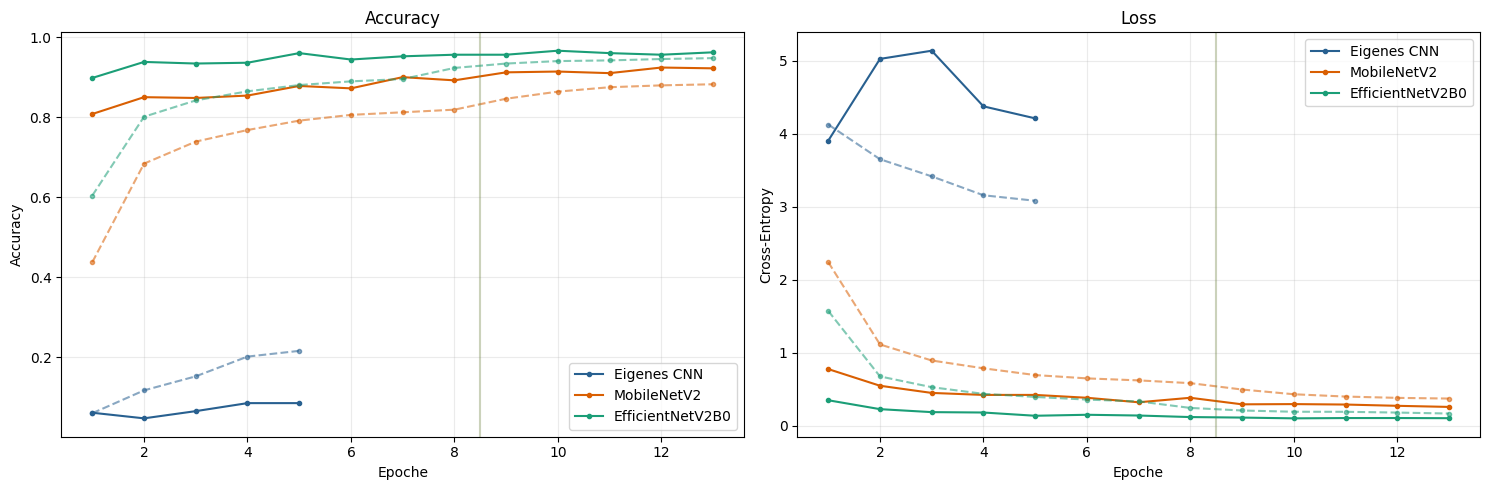

In [ ]:
def combined_metric(model_name, metric):
    head_values = list(histories[model_name]["head"].get(metric, []))
    fine_values = list(histories[model_name]["fine"].get(metric, []))
    return head_values + fine_values


colors = {
    "Eigenes CNN": "#286090",
    "MobileNetV2": "#d95f02",
    "EfficientNetV2B0": "#1b9e77",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model_name in models:
    train_acc = combined_metric(model_name, "accuracy")
    val_acc = combined_metric(model_name, "val_accuracy")
    epochs = np.arange(1, len(train_acc) + 1)
    axes[0].plot(
        epochs,
        train_acc,
        color=colors[model_name],
        alpha=0.55,
        linestyle="--",
        marker="o",
        markersize=3,
    )
    axes[0].plot(
        epochs,
        val_acc,
        color=colors[model_name],
        label=model_name,
        marker="o",
        markersize=3,
    )

    train_loss = combined_metric(model_name, "loss")
    val_loss = combined_metric(model_name, "val_loss")
    axes[1].plot(
        epochs,
        train_loss,
        color=colors[model_name],
        alpha=0.55,
        linestyle="--",
        marker="o",
        markersize=3,
    )
    axes[1].plot(
        epochs,
        val_loss,
        color=colors[model_name],
        label=model_name,
        marker="o",
        markersize=3,
    )

    boundary = len(histories[model_name]["head"].get("loss", []))
    if histories[model_name]["fine"] and boundary:
        for ax in axes:
            ax.axvline(boundary + 0.5, color=colors[model_name], alpha=0.20)

axes[0].set(title="Accuracy", xlabel="Epoche", ylabel="Accuracy")
axes[1].set(title="Loss", xlabel="Epoche", ylabel="Cross-Entropy")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## 9. Auswertung auf dem Testsplit

Im Testsplit gibt es nur fünf Bilder pro Klasse. Die Klassen sind damit zwar gleich groß, einzelne Fehler
haben aber relativ viel Einfluss. Wir ändern nach dieser Auswertung keine Hyperparameter mehr.

Verglichen werden Test-Loss, Top-1-Accuracy, Macro-F1, Top-5-Accuracy, Modellgröße und Trainingszeit.


In [ ]:
def collect_labels_and_images(dataset):
    image_batches = []
    label_batches = []
    for images, labels in dataset:
        image_batches.append(images.numpy())
        label_batches.append(labels.numpy())
    return np.concatenate(label_batches), np.concatenate(image_batches)


y_true, test_images = collect_labels_and_images(test_eval_ds)
y_prob_by_model = {}
y_pred_by_model = {}
result_rows = []

for model_name, model in models.items():
    evaluation = model.evaluate(test_eval_ds, verbose=0, return_dict=True)
    probabilities = model.predict(test_eval_ds, verbose=0)
    predictions = probabilities.argmax(axis=1)
    validation_accuracy = combined_metric(model_name, "val_accuracy")
    validation_loss = combined_metric(model_name, "val_loss")

    assert len(predictions) == len(y_true)
    y_prob_by_model[model_name] = probabilities
    y_pred_by_model[model_name] = predictions

    top5 = np.argsort(probabilities, axis=1)[:, -5:]
    top5_accuracy = np.mean(
        [target in candidates for target, candidates in zip(y_true, top5)]
    )

    result_rows.append(
        {
            "Modell": model_name,
            "Parameter": model.count_params(),
            "Trainierbare Parameter (final)": count_trainable_parameters(model),
            "Trainingszeit [s]": training_seconds[model_name],
            "Epochen": len(validation_loss),
            "Beste Val-Accuracy": max(validation_accuracy),
            "Niedrigster Val-Loss": min(validation_loss),
            "Test-Loss": evaluation["loss"],
            "Top-1-Accuracy": accuracy_score(y_true, predictions),
            "Macro-F1": f1_score(
                y_true,
                predictions,
                average="macro",
                labels=np.arange(NUM_CLASSES),
                zero_division=0,
            ),
            "Top-5-Accuracy": top5_accuracy,
        }
    )

comparison = (
    pd.DataFrame(result_rows)
    .sort_values(["Macro-F1", "Top-1-Accuracy"], ascending=False)
    .reset_index(drop=True)
)

formatted_comparison = comparison.copy()
for column in [
    "Beste Val-Accuracy",
    "Niedrigster Val-Loss",
    "Test-Loss",
    "Top-1-Accuracy",
    "Macro-F1",
    "Top-5-Accuracy",
]:
    formatted_comparison[column] = formatted_comparison[column].map(
        lambda x: f"{x:.4f}"
    )
formatted_comparison["Trainingszeit [s]"] = formatted_comparison[
    "Trainingszeit [s]"
].map(lambda x: f"{x:.1f}")
display(formatted_comparison)

best_model_name = comparison.loc[0, "Modell"]
print(f"Bestes Modell nach Macro-F1: {best_model_name}")
if SMOKE_TEST:
    print("ACHTUNG: Dies sind nur Smoke-Test-Werte und keine Endergebnisse.")

,Modell,Parameter,Trainierbare Parameter (final),Trainingszeit [s],Epochen,Beste Val-Accuracy,Niedrigster Val-Loss,Test-Loss,Top-1-Accuracy,Macro-F1,Top-5-Accuracy
0,EfficientNetV2B0,6272948,2570612,1175.7,13,0.9660,0.1040,0.1055,0.9680,0.9667,1.0000
1,MobileNetV2,2611620,1956516,1203.8,13,0.9240,0.2604,0.2208,0.9280,0.9259,0.9960
2,Eigenes CNN,481348,480388,1401.6,5,0.0860,3.9069,3.8901,0.0780,0.0465,0.2600


Bestes Modell nach Macro-F1: EfficientNetV2B0


### Confusion Matrix und häufige Verwechslungen

Eine Confusion Matrix mit 100 Klassen ist ziemlich dicht. Deshalb zeigen wir die vollständige,
zeilenweise normalisierte Matrix und zusätzlich eine kleinere Tabelle mit den häufigsten konkreten
Verwechslungen. So ist schneller zu erkennen, welche Sportarten dem Modell Probleme machen.


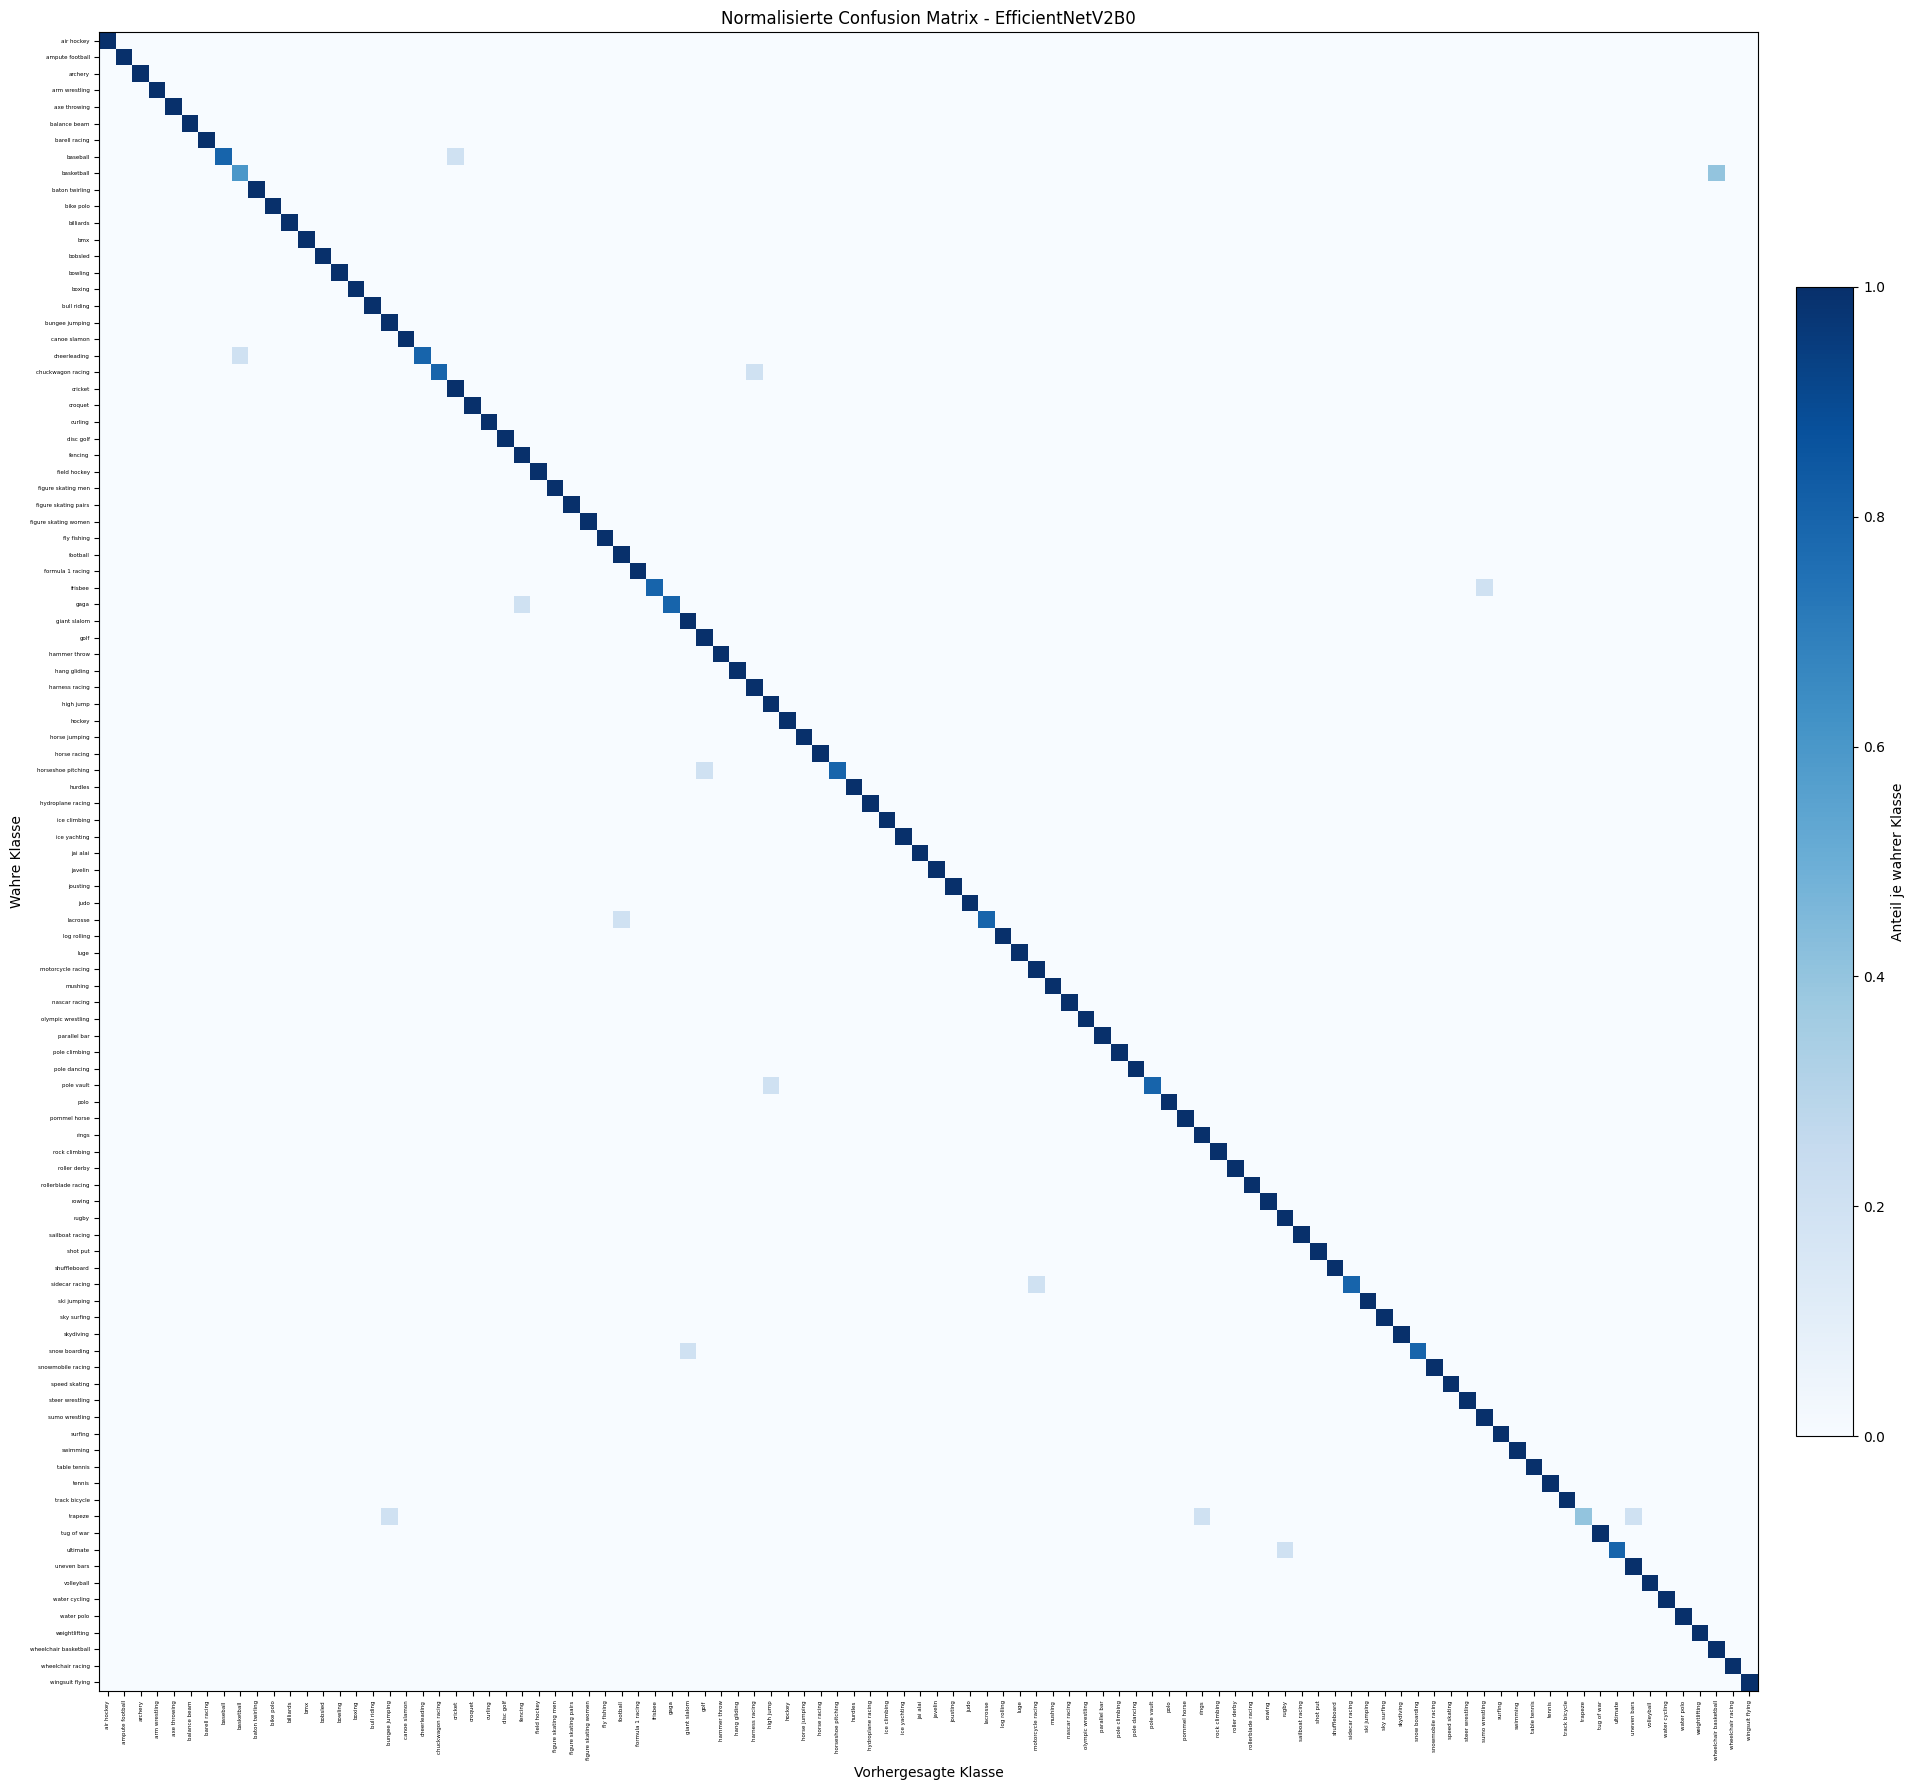

,Wahr,Vorhergesagt,Anzahl
1,basketball,wheelchair basketball,2
0,baseball,cricket,1
2,cheerleading,basketball,1
3,chuckwagon racing,harness racing,1
4,frisbee,sumo wrestling,1
5,gaga,fencing,1
6,horseshoe pitching,golf,1
7,lacrosse,football,1
8,pole vault,high jump,1
9,sidecar racing,motorcycle racing,1


In [ ]:
best_predictions = y_pred_by_model[best_model_name]
cm_counts = confusion_matrix(y_true, best_predictions, labels=np.arange(NUM_CLASSES))
cm_normalized = confusion_matrix(
    y_true,
    best_predictions,
    labels=np.arange(NUM_CLASSES),
    normalize="true",
)

fig, ax = plt.subplots(figsize=(20, 18))
image = ax.imshow(cm_normalized, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
ax.set(
    title=f"Normalisierte Confusion Matrix - {best_model_name}",
    xlabel="Vorhergesagte Klasse",
    ylabel="Wahre Klasse",
)
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=90, fontsize=4)
ax.set_yticklabels(class_names, fontsize=4)
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02, label="Anteil je wahrer Klasse")
plt.tight_layout()
plt.show()

confusion_rows = []
for true_index in range(NUM_CLASSES):
    for pred_index in range(NUM_CLASSES):
        if true_index != pred_index and cm_counts[true_index, pred_index] > 0:
            confusion_rows.append(
                {
                    "Wahr": class_names[true_index],
                    "Vorhergesagt": class_names[pred_index],
                    "Anzahl": int(cm_counts[true_index, pred_index]),
                }
            )

top_confusions = (
    pd.DataFrame(confusion_rows).sort_values("Anzahl", ascending=False).head(15)
    if confusion_rows
    else pd.DataFrame(columns=["Wahr", "Vorhergesagt", "Anzahl"])
)
display(top_confusions)

### Beispiele für richtige und falsche Vorhersagen

Wir zeigen nicht einfach vier zufällige Bilder. Bei den richtigen Vorhersagen werden verschiedene
Konfidenzen ausgewählt. Bei den Fehlern sind sowohl sehr sichere als auch unsichere Entscheidungen dabei.
Das macht die Beispiele aussagekräftiger.


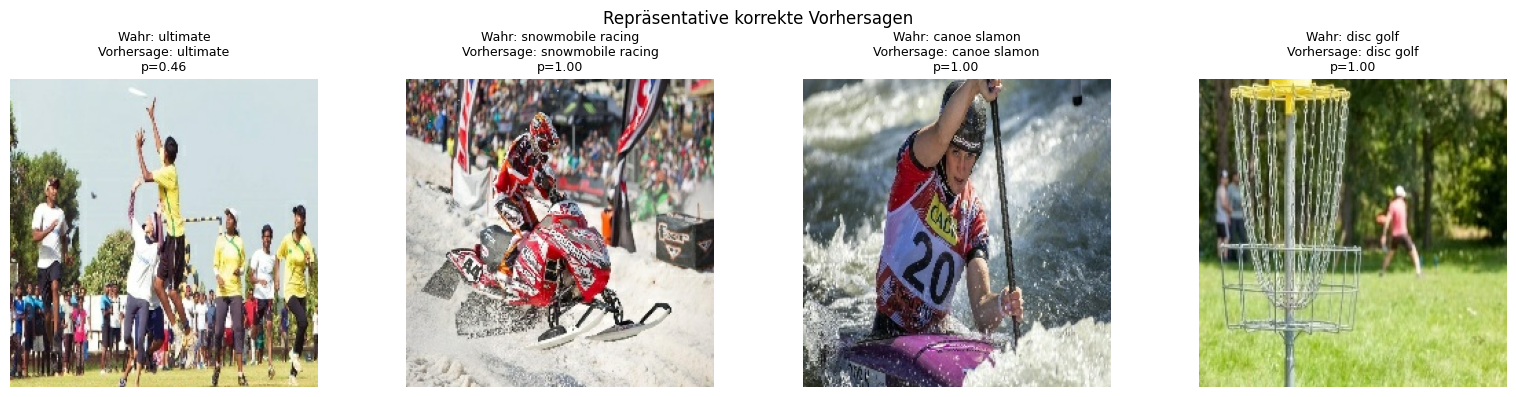

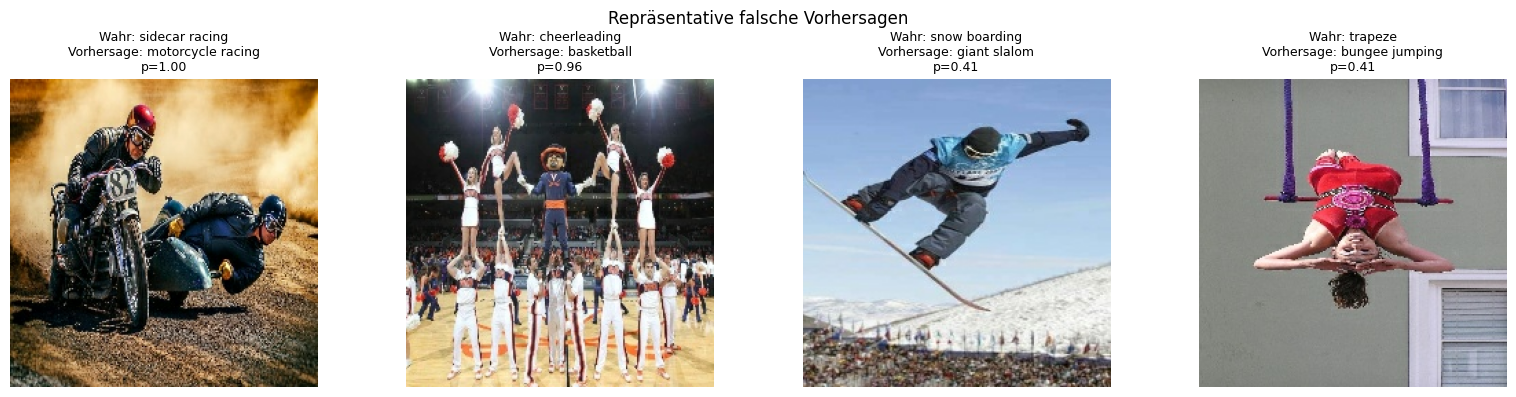

Korrekte Vorhersagen: 484/500
Falsche Vorhersagen: 16/500
Mittlere Konfidenz korrekt: 0.972
Mittlere Konfidenz falsch: 0.691
Selbstsicherster Fehler: sidecar racing -> motorcycle racing (p=0.995)


In [ ]:
best_probabilities = y_prob_by_model[best_model_name]
confidence = best_probabilities.max(axis=1)
correct_indices = np.flatnonzero(best_predictions == y_true)
incorrect_indices = np.flatnonzero(best_predictions != y_true)


def representative_indices(indices, n=4, prefer_errors=False):
    if len(indices) == 0:
        return []
    ordered = indices[np.argsort(confidence[indices])]
    if prefer_errors:
        candidates = list(ordered[-min(2, len(ordered)) :][::-1])
        candidates += list(ordered[: min(2, len(ordered))])
    else:
        positions = np.linspace(0, len(ordered) - 1, min(n, len(ordered))).astype(int)
        candidates = list(ordered[positions])
    return list(dict.fromkeys(candidates))[:n]


def plot_prediction_examples(indices, title):
    if not indices:
        print(f"Keine Beispiele für: {title}")
        return
    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    axes = np.atleast_1d(axes)
    for ax, index in zip(axes, indices):
        ax.imshow(np.clip(test_images[index], 0, 255).astype("uint8"))
        true_name = class_names[int(y_true[index])]
        pred_name = class_names[int(best_predictions[index])]
        ax.set_title(
            f"Wahr: {true_name}\nVorhersage: {pred_name}\np={confidence[index]:.2f}",
            fontsize=9,
        )
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


selected_correct = representative_indices(correct_indices, n=4)
selected_incorrect = representative_indices(incorrect_indices, n=4, prefer_errors=True)
plot_prediction_examples(selected_correct, "Repräsentative korrekte Vorhersagen")
plot_prediction_examples(selected_incorrect, "Repräsentative falsche Vorhersagen")

print(f"Korrekte Vorhersagen: {len(correct_indices)}/{len(y_true)}")
print(f"Falsche Vorhersagen: {len(incorrect_indices)}/{len(y_true)}")
if len(correct_indices):
    print(f"Mittlere Konfidenz korrekt: {confidence[correct_indices].mean():.3f}")
if len(incorrect_indices):
    print(f"Mittlere Konfidenz falsch: {confidence[incorrect_indices].mean():.3f}")
    most_confident_error = incorrect_indices[np.argmax(confidence[incorrect_indices])]
    print(
        "Selbstsicherster Fehler:",
        class_names[int(y_true[most_confident_error])],
        "->",
        class_names[int(best_predictions[most_confident_error])],
        f"(p={confidence[most_confident_error]:.3f})",
    )

## 10. Grad-CAM

Mit Grad-CAM möchten wir sehen, welche Bildbereiche für die Entscheidung des besten Transfer-Modells
wichtig waren. Warme Bereiche haben einen stärkeren Einfluss auf die vorhergesagte Klasse.

Interessant ist vor allem, ob das Modell auf Sportler, Sportgeräte oder Teile des Spielfelds schaut.
Wenn hauptsächlich Hintergrund, Publikum, Wasserzeichen oder Bildränder markiert sind, wäre das eher
ein Hinweis auf unerwünschten Kontext-Bias.


Grad-CAM-Modell: EfficientNetV2B0
Letzte räumliche Backbone-Schicht: top_activation


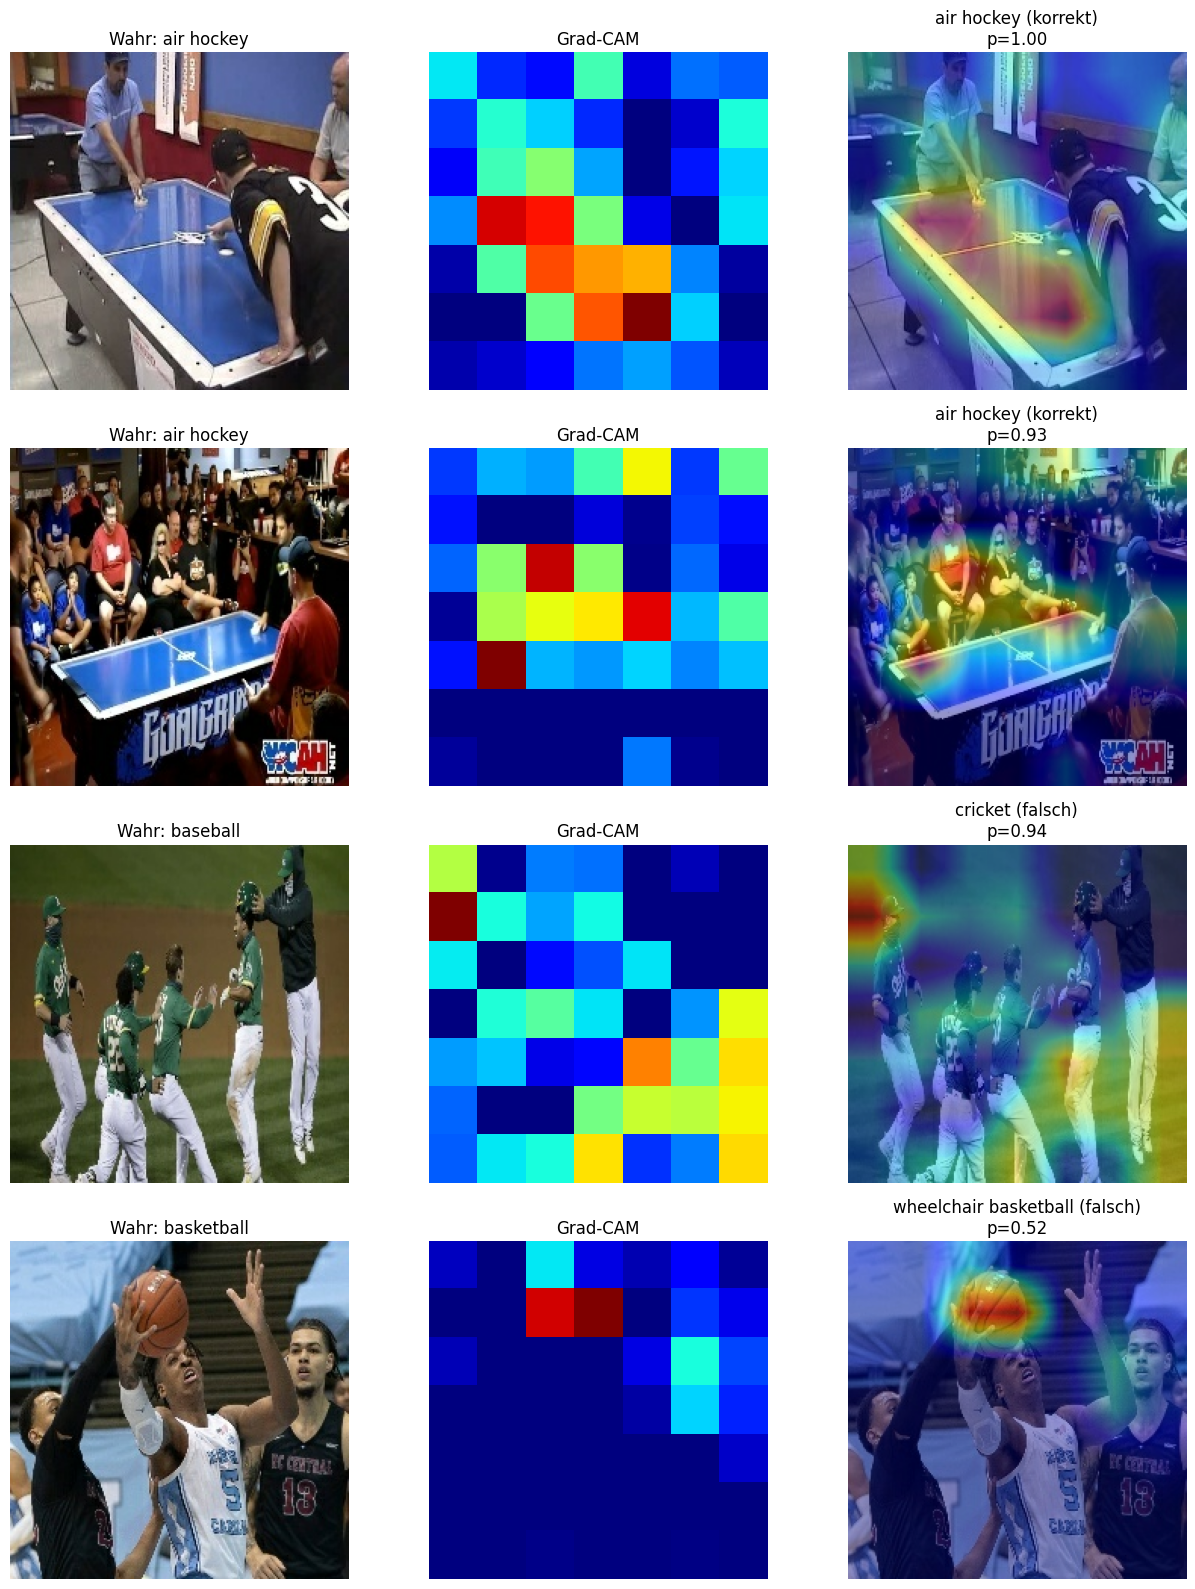

In [ ]:
transfer_names = ["MobileNetV2", "EfficientNetV2B0"]
best_transfer_name = (
    comparison[comparison["Modell"].isin(transfer_names)]
    .sort_values(["Macro-F1", "Top-1-Accuracy"], ascending=False)
    .iloc[0]["Modell"]
)
gradcam_model = models[best_transfer_name]
gradcam_probabilities = y_prob_by_model[best_transfer_name]
gradcam_predictions = y_pred_by_model[best_transfer_name]
components = transfer_components[best_transfer_name]
base = components["base"]
preprocessing = components["preprocessing"]
head = components["head"]

last_spatial_layer = None
for layer in reversed(base.layers):
    try:
        if len(layer.output.shape) == 4:
            last_spatial_layer = layer
            break
    except Exception:
        continue
assert last_spatial_layer is not None
print("Grad-CAM-Modell:", best_transfer_name)
print("Letzte räumliche Backbone-Schicht:", last_spatial_layer.name)

feature_model = keras.Model(
    base.inputs,
    [last_spatial_layer.output, base.output],
    name=f"{best_transfer_name}_gradcam_features",
)


def make_gradcam_heatmap(raw_image, class_index):
    image_batch = np.expand_dims(raw_image, axis=0)
    processed = preprocessing(image_batch, training=False)
    with tf.GradientTape() as tape:
        conv_output, features = feature_model(processed, training=False)
        predictions = head(features, training=False)
        class_score = predictions[:, class_index]
    gradients = tape.gradient(class_score, conv_output)
    if gradients is None:
        raise RuntimeError("Grad-CAM-Gradient konnte nicht berechnet werden.")
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_output[0] * pooled_gradients, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + keras.backend.epsilon()
    return heatmap.numpy()


gradcam_correct = np.flatnonzero(gradcam_predictions == y_true)
gradcam_incorrect = np.flatnonzero(gradcam_predictions != y_true)
gradcam_indices = list(gradcam_correct[:2]) + list(gradcam_incorrect[:2])
if len(gradcam_indices) < min(4, len(y_true)):
    remaining = [i for i in range(len(y_true)) if i not in gradcam_indices]
    gradcam_indices += remaining[: 4 - len(gradcam_indices)]

fig, axes = plt.subplots(
    len(gradcam_indices),
    3,
    figsize=(13, 4 * len(gradcam_indices)),
    squeeze=False,
)
for row, index in enumerate(gradcam_indices):
    raw_image = test_images[index]
    predicted_index = int(gradcam_predictions[index])
    heatmap = make_gradcam_heatmap(raw_image, predicted_index)
    resized_heatmap = (
        tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    )

    axes[row, 0].imshow(np.clip(raw_image, 0, 255).astype("uint8"))
    axes[row, 0].set_title(f"Wahr: {class_names[int(y_true[index])]}")
    axes[row, 1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
    axes[row, 1].set_title("Grad-CAM")
    axes[row, 2].imshow(np.clip(raw_image, 0, 255).astype("uint8"))
    axes[row, 2].imshow(resized_heatmap, cmap="jet", alpha=0.42, vmin=0, vmax=1)
    correctness = "korrekt" if predicted_index == int(y_true[index]) else "falsch"
    axes[row, 2].set_title(
        f"{class_names[predicted_index]} ({correctness})\n"
        f"p={gradcam_probabilities[index, predicted_index]:.2f}"
    )
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

## 11. Interpretation und Grenzen

Nach dem vollständigen Lauf achten wir bei der Auswertung besonders auf diese Punkte:

- **Leistung:** Die Transfer-Modelle sollten einen Vorteil haben, weil pro Klasse nur ungefähr
  135 Trainingsbilder vorhanden sind und ihre Backbones bereits allgemeine Bildmerkmale gelernt haben.
- **Trainingsverhalten:** Unser eigenes CNN muss alle Filter neu lernen und braucht deshalb vermutlich
  mehr Epochen. Beim Start des Fine-Tunings kann sich der Verlauf kurz verändern.
- **Fehler:** Bei den häufigsten Verwechslungen prüfen wir, ob die Sportarten ähnliche Körperhaltungen,
  Geräte oder Umgebungen haben.
- **Grad-CAM:** Wir prüfen, ob die markierten Bereiche fachlich sinnvoll aussehen oder ob das Modell
  hauptsächlich den Hintergrund verwendet.

Eine wichtige Einschränkung ist der kleine Testsplit. Pro Klasse gibt es nur fünf Bilder. Ein einzelner
Fehler verändert die Trefferquote dieser Klasse also schon um 20 Prozentpunkte. Die Ergebnisse gelten
außerdem nur für Version 9, den Seed und die hier gewählten Einstellungen. Für stabilere Aussagen müssten
wir mehrere Trainingsläufe mit verschiedenen Seeds durchführen.


In [ ]:
best_row = comparison.iloc[0]
print("Automatische Ergebniszusammenfassung")
print("--------------------------------")
print(
    f"Nach Macro-F1 liegt {best_row['Modell']} vorne "
    f"(Accuracy={best_row['Top-1-Accuracy']:.3f}, "
    f"Macro-F1={best_row['Macro-F1']:.3f}, "
    f"Top-5={best_row['Top-5-Accuracy']:.3f})."
)
if not top_confusions.empty:
    pair = top_confusions.iloc[0]
    print(
        f"Häufigste beobachtete Fehlzuordnung: "
        f"{pair['Wahr']} -> {pair['Vorhergesagt']} "
        f"({int(pair['Anzahl'])} Bild(er))."
    )
if SMOKE_TEST:
    print(
        "Diese Zusammenfassung stammt aus dem Smoke-Test. "
        "Für die Abgabe muss das Notebook im Vollmodus neu ausgeführt werden."
    )

Automatische Ergebniszusammenfassung
--------------------------------
Nach Macro-F1 liegt EfficientNetV2B0 vorne (Accuracy=0.968, Macro-F1=0.967, Top-5=1.000).
Häufigste beobachtete Fehlzuordnung: basketball -> wheelchair basketball (2 Bild(er)).


## 12. Reproduzierbarkeit und vollständiger Lauf

- Seed: `42`
- Datensatz: `gpiosenka/sports-classification`, Version 9
- verwendete Keras- und TensorFlow-Versionen werden am Anfang ausgegeben
- Validierungs- und Testdaten bleiben in einer festen Reihenfolge
- die vortrainierten Gewichte stammen aus ImageNet

Für die endgültigen Ergebnisse starten wir den Kernel ohne `UE2_SMOKE_TEST` neu und führen wir alle Zellen von
oben nach unten aus. Wegen der drei Modelle mit 224×224-Eingaben ist dafür eine GPU sinnvoll. Beim ersten
Start werden ungefähr 453 MB Datensatzdaten und zusätzlich die beiden ImageNet-Backbones heruntergeladen.


## 13. LLM-Nutzung

Für die Struktur, einzelne Formulierungen, den Codeentwurf und die Fehlersuche wurde OpenAI Codex
verwendet. Anschließend wurde das Notebook vollständig im Smoke-Test ausgeführt.
